# Visualizing On- and Off-Target Morphological Signatures

This notebook evaluates whether our morphological signatures effectively capture phenotypic differences. We apply PCA and UMAP to reduce the feature space to two dimensions and visualize the distribution of DMSO (negative control) and TGFRi (positive control) treated cells at the single-cell level.

What do we expect:
- On-Target Signature Analysis: We expect to see distinct clusters separating DMSO and TGFRi-treated cells. Clear separation indicates that these features successfully capture the morphological differences induced by TGFβ receptor inhibition.
- Off-Target Signature Analysis: We expect to see significant overlap (mixing) between treatment groups. This confirms that these features do not distinguish between the phenotypes, serving as a negative control for our feature selection process.

We create two types of plots for both PCA and UMAP:
1. **Overlay plots**: Both treatment groups shown together to assess overall separation
2. **Faceted plots**: Individual treatment groups displayed separately to examine within-group distributions

In [ ]:
import sys
import pathlib
import polars as pl

import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sys.path.append("../../../")
from utils.io_utils import load_profiles, load_configs
from utils.data_utils import split_meta_and_features

Setting up input and output paths

In [2]:
seed = 0

In [3]:
# setting results path
results_dir = pathlib.Path("../results").resolve(strict=True)
buscar_results_dir = pathlib.Path("./results").resolve(strict=True)

# setting on- and off mophlgoical signature path
signatures_path = (results_dir / "cfret_pilot_signatures.json").resolve()

# setting cfret-pilot data path
data_dir = pathlib.Path("../../0.download-data/data/sc-profiles").resolve()

# setting cfret-screen data path
cfret_pilot_profiles_path = (
    data_dir / "cfret/localhost230405150001_sc_feature_selected.parquet"
).resolve(strict=True)

# setting results path
results_dir = pathlib.Path("./results").resolve()
results_dir.mkdir(exist_ok=True)

# setting pca subdir
pca_dir = (results_dir / "pca").resolve()
pca_dir.mkdir(exist_ok=True)
umap_dir = (results_dir / "umap").resolve()
umap_dir.mkdir(exist_ok=True)

# setting plots folder and pca
plots_dir = (results_dir / "plots").resolve()
plots_dir.mkdir(exist_ok=True)

In [4]:
# loading profiles and signatures
signatures = load_configs(signatures_path)
cfret_profiles_df = load_profiles(cfret_pilot_profiles_path)

# filter to only DMSO and TGFRi treated (since these was the ref and targeted conditions)
cfret_profiles_df = cfret_profiles_df.filter(
    (pl.col("Metadata_treatment") == "DMSO") | (pl.col("Metadata_treatment") == "TGFRi")
)

cfret_meta, cfret_feats = split_meta_and_features(cfret_profiles_df)

In [5]:
# count cells within Metadata_treatment
cell_count_df = cfret_profiles_df.group_by("Metadata_treatment").len()
cell_count_df

Metadata_treatment,len
str,u32
"""TGFRi""",5274
"""DMSO""",10519


In [6]:
# separate on and off morpholgoical profiles
on_profiles_df = cfret_profiles_df.select(pl.col(signatures["on"]))
off_profiles_df = cfret_profiles_df.select(pl.col(signatures["off"]))

## Plotting PCA componenets 

In [7]:
# create pca components for on and off profiles
pca_model = PCA(n_components=2, random_state=seed)
pca_on_result = pca_model.fit_transform(on_profiles_df.to_numpy())
pca_off_result = pca_model.fit_transform(off_profiles_df.to_numpy())


# add metadata to pca results
pca_off_df = pl.concat(
    [
        cfret_profiles_df.select(pl.col(cfret_meta)),
        pl.DataFrame(pca_off_result, schema=["PC1", "PC2"]),
    ],
    how="horizontal",
)
pca_on_df = pl.concat(
    [
        cfret_profiles_df.select(pl.col(cfret_meta)),
        pl.DataFrame(pca_on_result, schema=["PC1", "PC2"]),
    ],
    how="horizontal",
)

# save components
pca_on_df.write_parquet(pca_dir / "cfret_pilot_on_pca.parquet")
pca_off_df.write_parquet(pca_dir / "cfret_pilot_off_pca.parquet")

# print shapes
print("PCA ON shape:", pca_on_df.shape)
print("PCA OFF shape:", pca_off_df.shape)

PCA ON shape: (15793, 22)
PCA OFF shape: (15793, 22)


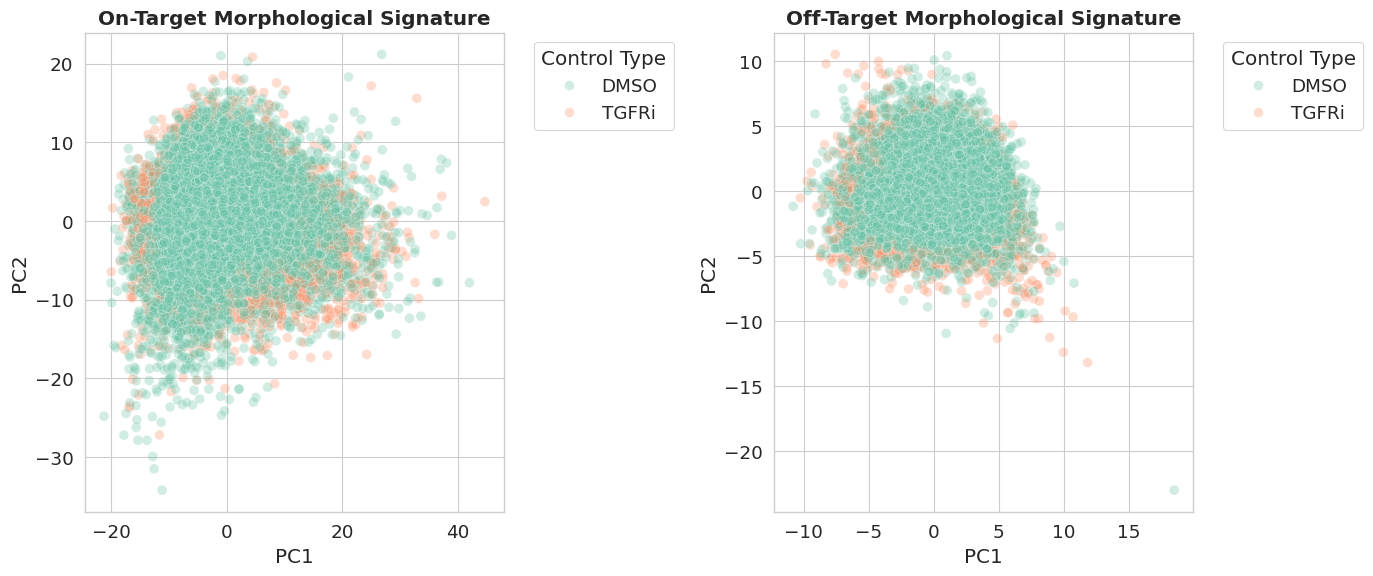

In [ ]:
# set style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# create figure with two subplots horizontally
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# plot on-target PCA
sns.scatterplot(
    data=pca_on_df.to_pandas(),
    x="PC1",
    y="PC2",
    hue="Metadata_treatment",  # adjust column name as needed
    palette="Set2",
    alpha=0.3,
    s=50,
    ax=axes[0],
)
axes[0].set_title("On-Target Morphological Signature", fontweight="bold")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc="upper left")

# plot off-target PCA
sns.scatterplot(
    data=pca_off_df.to_pandas(),
    x="PC1",
    y="PC2",
    hue="Metadata_treatment",  # adjust column name as needed
    palette="Set2",
    alpha=0.3,
    s=50,
    ax=axes[1],
)
axes[1].set_title("Off-Target Morphological Signature", fontweight="bold")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc="upper left")

# adjust layout
plt.tight_layout()

# save figure
plt.savefig(plots_dir / "pca_on_off_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

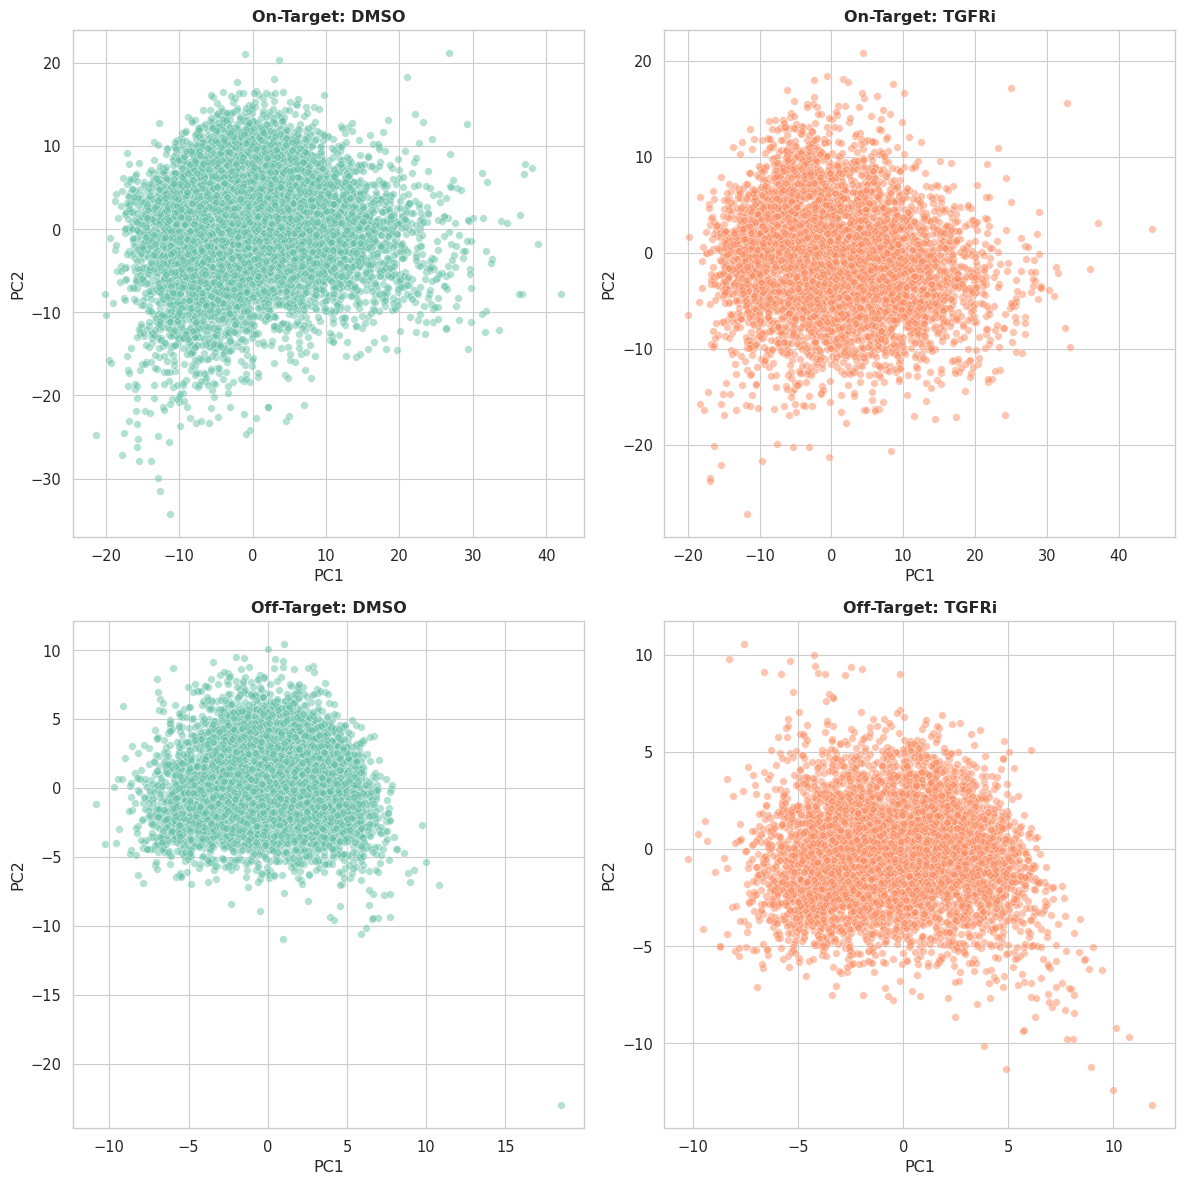

In [ ]:
# set style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# define treatments and colors
treatments = ["DMSO", "TGFRi"]
colors = ["#66c2a5", "#fc8d62"]  # colors from Set2 palette

# top row: on-target morphological signatures
for i, treatment in enumerate(treatments):
    data_subset = pca_on_df.filter(pl.col("Metadata_treatment") == treatment)

    sns.scatterplot(
        data=data_subset.to_pandas(),
        x="PC1",
        y="PC2",
        color=colors[i],
        alpha=0.5,
        s=30,
        ax=axes[0, i],
    )
    axes[0, i].set_title(f"On-Target: {treatment}", fontweight="bold")
    axes[0, i].set_xlabel("PC1")
    axes[0, i].set_ylabel("PC2")

# bottom row: off-target morphological signatures
for i, treatment in enumerate(treatments):
    data_subset = pca_off_df.filter(pl.col("Metadata_treatment") == treatment)

    sns.scatterplot(
        data=data_subset.to_pandas(),
        x="PC1",
        y="PC2",
        color=colors[i],
        alpha=0.5,
        s=30,
        ax=axes[1, i],
    )
    axes[1, i].set_title(f"Off-Target: {treatment}", fontweight="bold")
    axes[1, i].set_xlabel("PC1")
    axes[1, i].set_ylabel("PC2")

# adjust layout
plt.tight_layout()

# save figure
plt.savefig(plots_dir / "pca_facet_grid.png", dpi=300, bbox_inches="tight")
plt.show()

## Plotting UMAP plots 

In [10]:
# create umap components for on and off profiles
umap_model = umap.UMAP(n_components=2, random_state=seed)
umap_on_result = umap_model.fit_transform(on_profiles_df.to_numpy())
umap_off_result = umap_model.fit_transform(off_profiles_df.to_numpy())


# add metadata to umap results
umap_off_df = pl.concat(
    [
        cfret_profiles_df.select(pl.col(cfret_meta)),
        pl.DataFrame(umap_off_result, schema=["UMAP1", "UMAP2"]),
    ],
    how="horizontal",
)
umap_on_df = pl.concat(
    [
        cfret_profiles_df.select(pl.col(cfret_meta)),
        pl.DataFrame(umap_on_result, schema=["UMAP1", "UMAP2"]),
    ],
    how="horizontal",
)

# save umap plots
umap_on_df.write_parquet(umap_dir / "cfret_pilot_on_umap.parquet")
umap_off_df.write_parquet(umap_dir / "cfret_pilot_off_umap.parquet")

# print shapes
print("UMAP ON shape:", umap_on_df.shape)
print("UMAP OFF shape:", umap_off_df.shape)

/home/erikserrano/Software/miniconda3/envs/buscar/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP ON shape: (15793, 22)
UMAP OFF shape: (15793, 22)


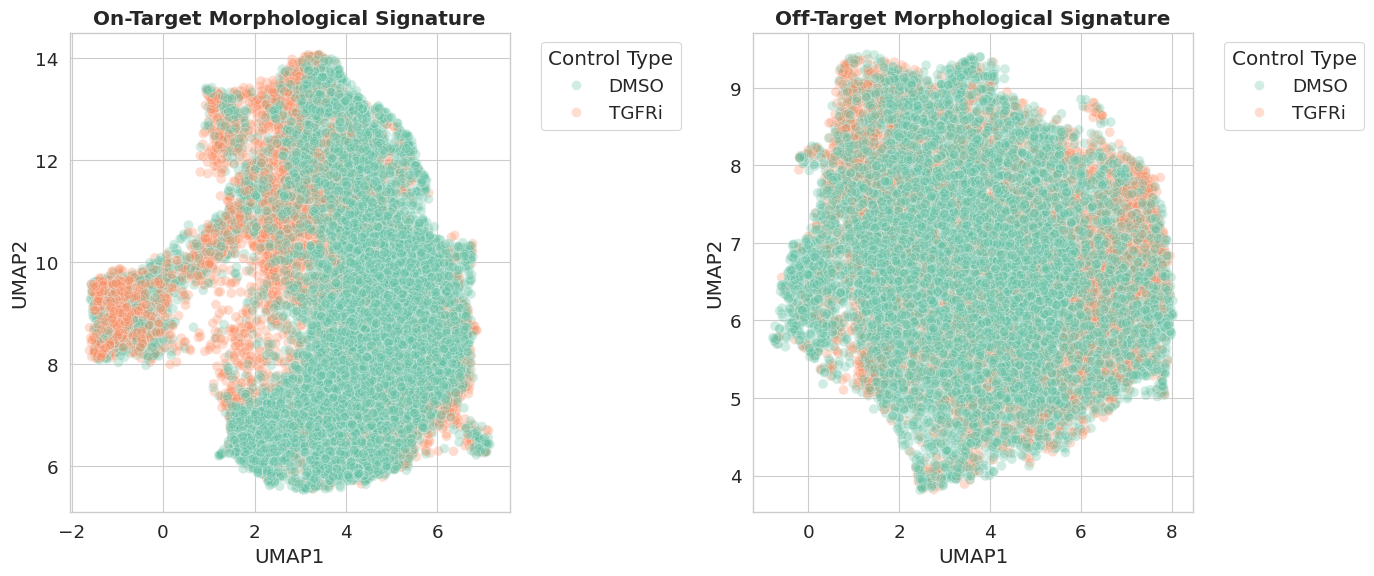

In [ ]:
# set style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# create figure with two subplots horizontally
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# plot on-target UMAP
sns.scatterplot(
    data=umap_on_df.to_pandas(),
    x="UMAP1",
    y="UMAP2",
    hue="Metadata_treatment",
    palette="Set2",
    alpha=0.3,
    s=50,
    ax=axes[0],
)
axes[0].set_title("On-Target Morphological Signature", fontweight="bold")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")
axes[0].legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc="upper left")

# plot off-target UMAP
sns.scatterplot(
    data=umap_off_df.to_pandas(),
    x="UMAP1",
    y="UMAP2",
    hue="Metadata_treatment",
    palette="Set2",
    alpha=0.3,
    s=50,
    ax=axes[1],
)
axes[1].set_title("Off-Target Morphological Signature", fontweight="bold")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")
axes[1].legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc="upper left")

# adjust layout
plt.tight_layout()

# save figure
plt.savefig(plots_dir / "umap_on_off_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

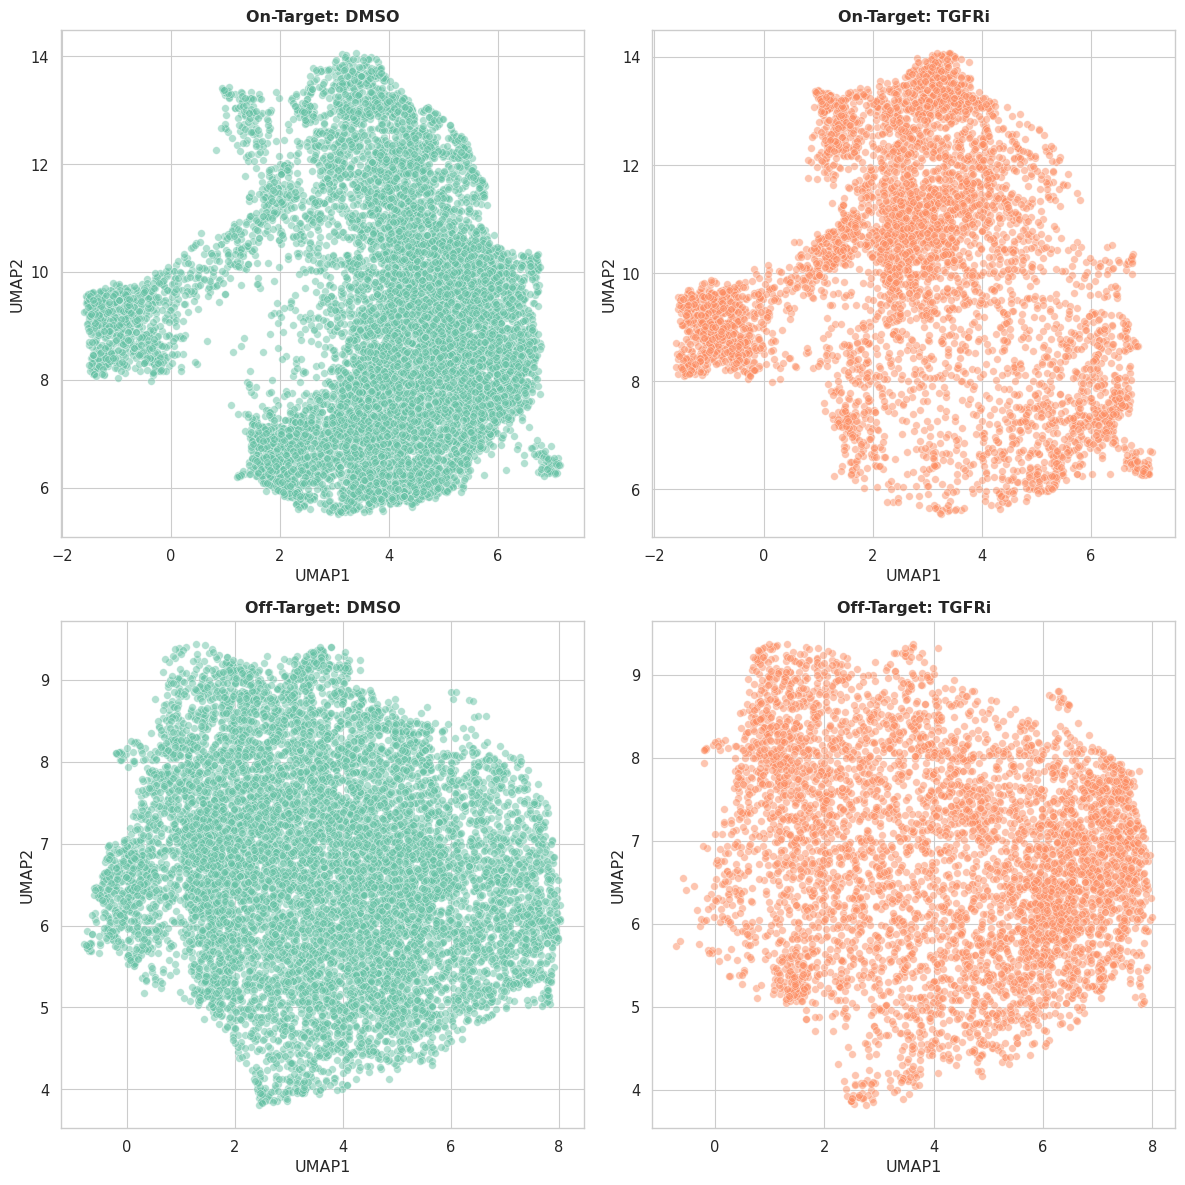

In [12]:
# set publication style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# define treatments and colors
treatments = ["DMSO", "TGFRi"]
colors = ["#66c2a5", "#fc8d62"]  # colors from Set2 palette

# top row: on-target morphological signatures
for i, treatment in enumerate(treatments):
    data_subset = umap_on_df.filter(pl.col("Metadata_treatment") == treatment)

    sns.scatterplot(
        data=data_subset.to_pandas(),
        x="UMAP1",
        y="UMAP2",
        color=colors[i],
        alpha=0.5,
        s=30,
        ax=axes[0, i],
    )
    axes[0, i].set_title(f"On-Target: {treatment}", fontweight="bold")
    axes[0, i].set_xlabel("UMAP1")
    axes[0, i].set_ylabel("UMAP2")

# bottom row: off-target morphological signatures
for i, treatment in enumerate(treatments):
    data_subset = umap_off_df.filter(pl.col("Metadata_treatment") == treatment)

    sns.scatterplot(
        data=data_subset.to_pandas(),
        x="UMAP1",
        y="UMAP2",
        color=colors[i],
        alpha=0.5,
        s=30,
        ax=axes[1, i],
    )
    axes[1, i].set_title(f"Off-Target: {treatment}", fontweight="bold")
    axes[1, i].set_xlabel("UMAP1")
    axes[1, i].set_ylabel("UMAP2")

# adjust layout
plt.tight_layout()

# save figure
plt.savefig(plots_dir / "umap_facet_grid.png", dpi=300, bbox_inches="tight")
plt.show()